# Your accuracy is flat and your probabilities are wrong

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## The simulation

In [1]:
import numpy as np
rng = np.random.default_rng(0)
sigmoid = lambda z: 1 / (1 + np.exp(-z))

def ece(p, y, M=15):
    """ECE on the positive-class probability, M equal-width bins on [0, 1]."""
    b = np.minimum((p * M).astype(int), M - 1)
    return sum((b == m).mean() * abs(y[b == m].mean() - p[b == m].mean())
               for m in range(M) if (b == m).any())

def month_of_traffic(n, scale):
    z = rng.normal(0, 1.4, n)                    # true log-odds
    y = (rng.random(n) < sigmoid(z)).astype(int)
    return sigmoid(scale * z), y                 # served probability, label

n = 20_000                                       # labeled rows per month
print("month  scale  accuracy     ECE")
for month, scale in enumerate([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]):
    p, y = month_of_traffic(n, scale)
    acc = np.mean((p >= 0.5) == (y == 1))
    print(f"{month:5d}  {scale:5.1f}  {acc:8.3f}  {ece(p, y):.4f}")
print(f"month 6, served 0.9 -> true rate {sigmoid(np.log(9) / 1.6):.0%}")

thr = {}
for n_win in (1_000, 20_000):                    # calibrated model, noise only
    null = [ece(*month_of_traffic(n_win, 1.0)) for _ in range(500)]
    thr[n_win] = np.percentile(null, 99)         # alert threshold
    print(f"ECE null, n={n_win:>6,}: median {np.median(null):.4f}, "
          f"99th pct {np.percentile(null, 99):.4f}")

month  scale  accuracy     ECE
    0    1.0     0.722  0.0079
    1    1.1     0.724  0.0144
    2    1.2     0.724  0.0293
    3    1.3     0.729  0.0369
    4    1.4     0.718  0.0577
    5    1.5     0.724  0.0630
    6    1.6     0.723  0.0727
month 6, served 0.9 -> true rate 80%


ECE null, n= 1,000: median 0.0393, 99th pct 0.0590


ECE null, n=20,000: median 0.0088, 99th pct 0.0128


## Measuring drift with the population stability index

In [2]:
def psi(ref, cur, edges, eps=1e-6):
    """PSI = sum_k (c_k - r_k) log(c_k / r_k) on fixed reference edges."""
    r = np.bincount(np.searchsorted(edges, ref), minlength=len(edges) + 1) / len(ref)
    c = np.bincount(np.searchsorted(edges, cur), minlength=len(edges) + 1) / len(cur)
    r, c = np.maximum(r, eps), np.maximum(c, eps)
    return float(np.sum((c - r) * np.log(c / r)))

K = 10
for n_win in (1_000, 20_000):
    null, shifted = [], []
    for _ in range(500):
        ref = rng.normal(0, 1, n_win)            # last clean window
        edges = np.quantile(ref, np.linspace(0, 1, K + 1)[1:-1])
        null.append(psi(ref, rng.normal(0.0, 1, n_win), edges))
        shifted.append(psi(ref, rng.normal(0.1, 1, n_win), edges))
    print(f"PSI n={n_win:>6,}: null mean {np.mean(null):.4f}, median {np.median(null):.4f}, "
          f"99th pct {np.percentile(null, 99):.4f}, 2(K-1)/n {2*(K-1)/n_win:.4f}, "
          f"0.1-sigma shift median {np.median(shifted):.4f}")

for n_win, months in ((1_000, (3,)), (20_000, (1, 2))):   # ECE alert hit rates
    for mo in months:
        hits = [ece(*month_of_traffic(n_win, 1 + 0.1 * mo)) > thr[n_win] for _ in range(300)]
        print(f"ECE alert rate, n={n_win:>6,}, month {mo}: {np.mean(hits):.0%}")

PSI n= 1,000: null mean 0.0186, median 0.0177, 99th pct 0.0455, 2(K-1)/n 0.0180, 0.1-sigma shift median 0.0251


PSI n=20,000: null mean 0.0009, median 0.0008, 99th pct 0.0022, 2(K-1)/n 0.0009, 0.1-sigma shift median 0.0103


ECE alert rate, n= 1,000, month 3: 37%


ECE alert rate, n=20,000, month 1: 92%


ECE alert rate, n=20,000, month 2: 100%


## A staleness bound from the refresh schedule

In [3]:
t = np.random.default_rng(1).uniform(48, 48 + 24 * 60, 200_000)   # request times, hours

def served_age(t, delta, lag, missed=()):
    """Age of the value served at time t. Run k snapshots its inputs at k*delta
    and its output becomes readable at k*delta + lag."""
    k = np.floor((t - lag) / delta)             # latest run that has landed
    for _ in missed:                            # a failed run leaves the previous value
        k = np.where(np.isin(k, missed), k - 1, k)
    return t - k * delta                        # measured from the snapshot time

bound = 24 + 3                                  # contract for the nightly job: delta + L
for label, a in (("nightly, L = 3 h", served_age(t, 24, 3)),
                 ("one failed run", served_age(t, 24, 3, missed=[30])),
                 ("moved to every 48 h", served_age(t, 48, 3)),
                 ("landing slips to 9 h", served_age(t, 24, 9))):
    print(f"{label:21s} mean {a.mean():4.1f} h  max {a.max():4.1f} h  "
          f"over {bound} h: {np.mean(a > bound):5.1%}")

nightly, L = 3 h      mean 15.0 h  max 27.0 h  over 27 h:  0.0%
one failed run        mean 15.4 h  max 51.0 h  over 27 h:  1.7%
moved to every 48 h   mean 27.0 h  max 51.0 h  over 27 h: 50.0%
landing slips to 9 h  mean 21.0 h  max 33.0 h  over 27 h: 25.2%


## The figure

In [4]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

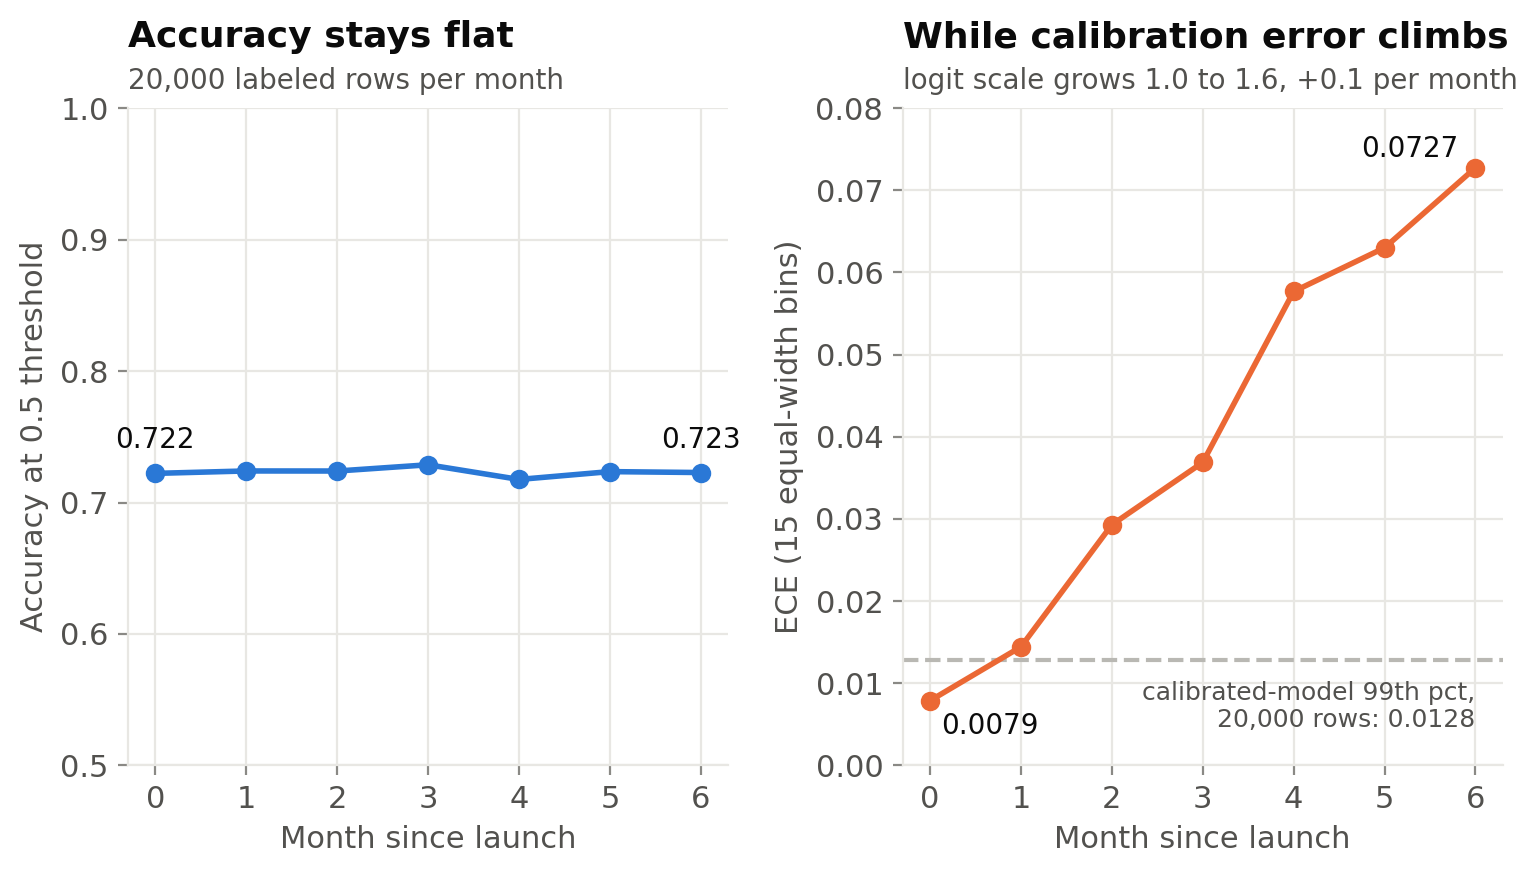

In [5]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # The article's first block, same seed and draw order
    rng = np.random.default_rng(0)
    sigmoid = lambda z: 1 / (1 + np.exp(-z))

    def ece(p, y, M=15):
        b = np.minimum((p * M).astype(int), M - 1)
        return sum((b == m).mean() * abs(y[b == m].mean() - p[b == m].mean())
                   for m in range(M) if (b == m).any())

    def month_of_traffic(n, scale):
        z = rng.normal(0, 1.4, n)
        y = (rng.random(n) < sigmoid(z)).astype(int)
        return sigmoid(scale * z), y

    n = 20_000
    months, accs, eces = [], [], []
    for month, scale in enumerate([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]):
        p, y = month_of_traffic(n, scale)
        months.append(month); accs.append(np.mean((p >= 0.5) == (y == 1))); eces.append(ece(p, y))
    thr = {}
    for n_win in (1_000, 20_000):
        null = [ece(*month_of_traffic(n_win, 1.0)) for _ in range(500)]
        thr[n_win] = np.percentile(null, 99)
    print([f"{a:.3f}" for a in accs], [f"{e:.4f}" for e in eces], f"{thr[20_000]:.4f}")

    f, (a1, a2) = fig(1, 2, sharex=True)
    a1.plot(months, accs, color=S1, marker="o")
    a1.set_ylim(0.5, 1.0)
    a1.annotate(f"{accs[0]:.3f}", (0, accs[0]), xytext=(0, 9), textcoords="offset points",
                ha="center", color=INK, fontsize=10)
    a1.annotate(f"{accs[-1]:.3f}", (6, accs[-1]), xytext=(0, 9), textcoords="offset points",
                ha="center", color=INK, fontsize=10)
    a1.set_ylabel("Accuracy at 0.5 threshold")
    a1.set_title("Accuracy stays flat")
    subtitle(a1, "20,000 labeled rows per month")

    a2.axhline(thr[20_000], color=NEUTRAL, lw=1.5, ls="--")
    a2.text(6, thr[20_000] - 0.0025, f"calibrated-model 99th pct,\n20,000 rows: {thr[20_000]:.4f}",
            color=INK_2, fontsize=9, ha="right", va="top")
    a2.plot(months, eces, color=S2, marker="o")
    a2.annotate(f"{eces[0]:.4f}", (0, eces[0]), xytext=(4, -12), textcoords="offset points",
                ha="left", color=INK, fontsize=10)
    a2.annotate(f"{eces[-1]:.4f}", (6, eces[-1]), xytext=(-6, 4), textcoords="offset points",
                ha="right", color=INK, fontsize=10)
    a2.set_ylim(0, 0.08)
    a2.set_ylabel("ECE (15 equal-width bins)")
    a2.set_title("While calibration error climbs")
    subtitle(a2, "logit scale grows 1.0 to 1.6, +0.1 per month")
    for ax in (a1, a2):
        ax.set_xlabel("Month since launch")
        ax.set_xticks(months)
    path = pathlib.Path(__file__).parent / "10-accuracy-vs-ece.png"
    save(f, path)
import matplotlib.pyplot as plt
plt.show()